Analysis to determine the feature correlation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import shap
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression

from utils.plot_utils import (
    save_plot,
    setup_plot_directory,
    save_plot_with_timestamp
    )

/opt/anaconda3/envs/GTHES/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Read the data.

In [2]:
notebook_path = Path.cwd()  # Get current working directory
project_root = notebook_path.parent  # Go up one level from ANALYTICS to CODES
csv_path = project_root /'DATA-CLEAN'/'PROCESSED'/'cleaned_proc_data_v1.csv'


# Read the data
df = pd.read_csv(csv_path)


In [3]:
df.describe()

,Procada Current,Procada Voltage,Laser Power,Wire Current,Wire Speed,Wire Voltage,X,Y,Z
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,28.965345,1.765583,3829.398000,0.044600,2.461910,0.017840,-430.759930,180.087668,151.534939
std,35.023862,1.989290,4420.988124,0.049732,2.600706,0.019893,55.500686,118.575226,6.431179
min,0.134100,0.000100,0.000000,0.000000,0.000000,0.000000,-491.213104,-21.173449,96.233009
25%,0.275200,0.004300,0.000000,0.000000,0.000000,0.000000,-476.894089,81.326271,151.504318
50%,0.275200,0.004300,0.000000,0.000000,0.000000,0.000000,-453.475479,170.617676,152.867928
75%,71.136600,3.863300,9020.000000,0.100000,5.240000,0.040000,-398.811897,278.328461,153.751873
max,76.389700,5.039200,9020.000000,0.100000,5.240000,0.040000,-286.253357,393.276672,157.679810


In [4]:
df.isnull().sum()

Timestamp          0
Datetime           0
Procada Current    0
Procada Voltage    0
Laser Power        0
Wire Current       0
Wire Speed         0
Wire Voltage       0
X                  0
Y                  0
Z                  0
dtype: int64

In [5]:
plot_dir = setup_plot_directory()

Correlation Matrix

<function matplotlib.pyplot.show(close=None, block=None)>

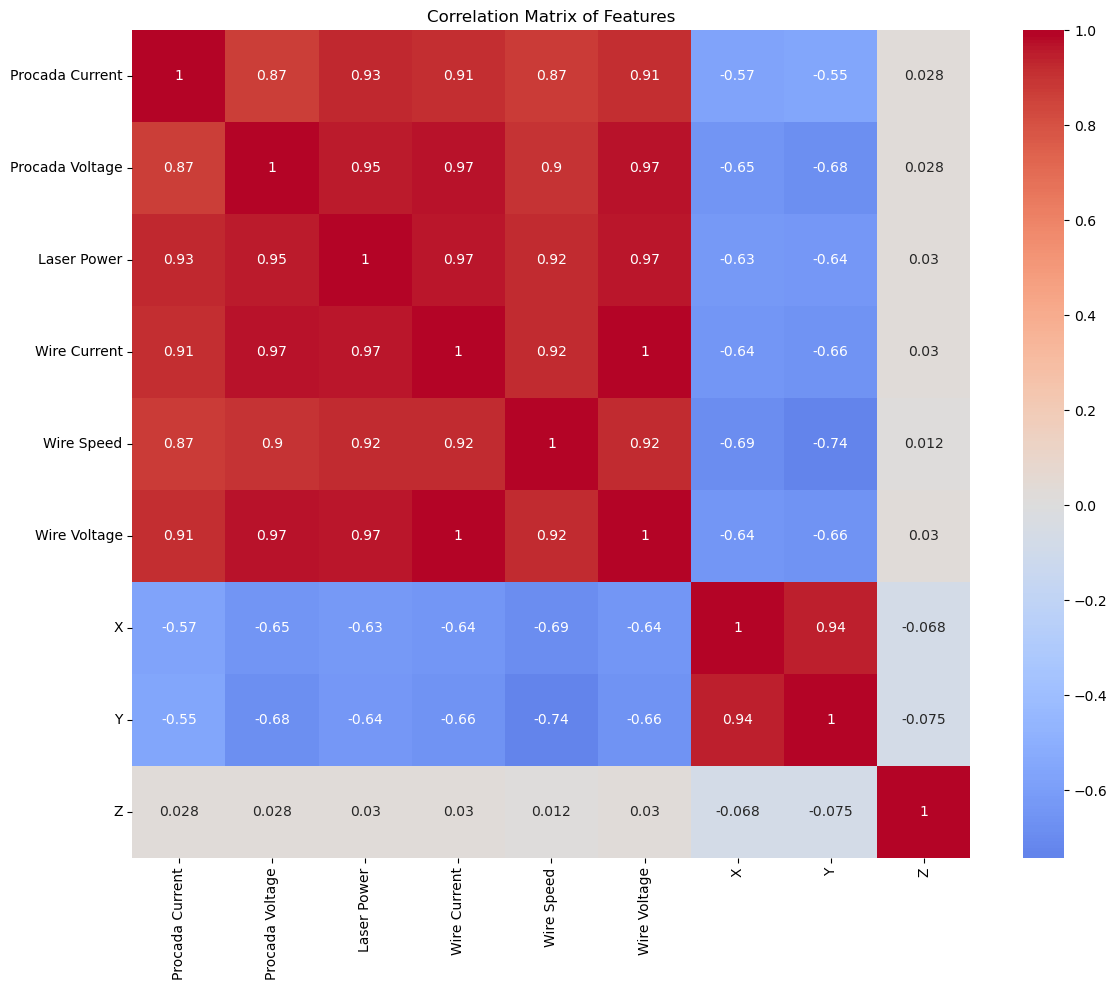

In [6]:
plt.figure(figsize = (12, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', center = 0)
plt.title('Correlation Matrix of Features')
plt.tight_layout()

save_plot(plt, 'correlation_matrix.png', plot_dir)
plt.show


Pairwise Scatter plots for key features

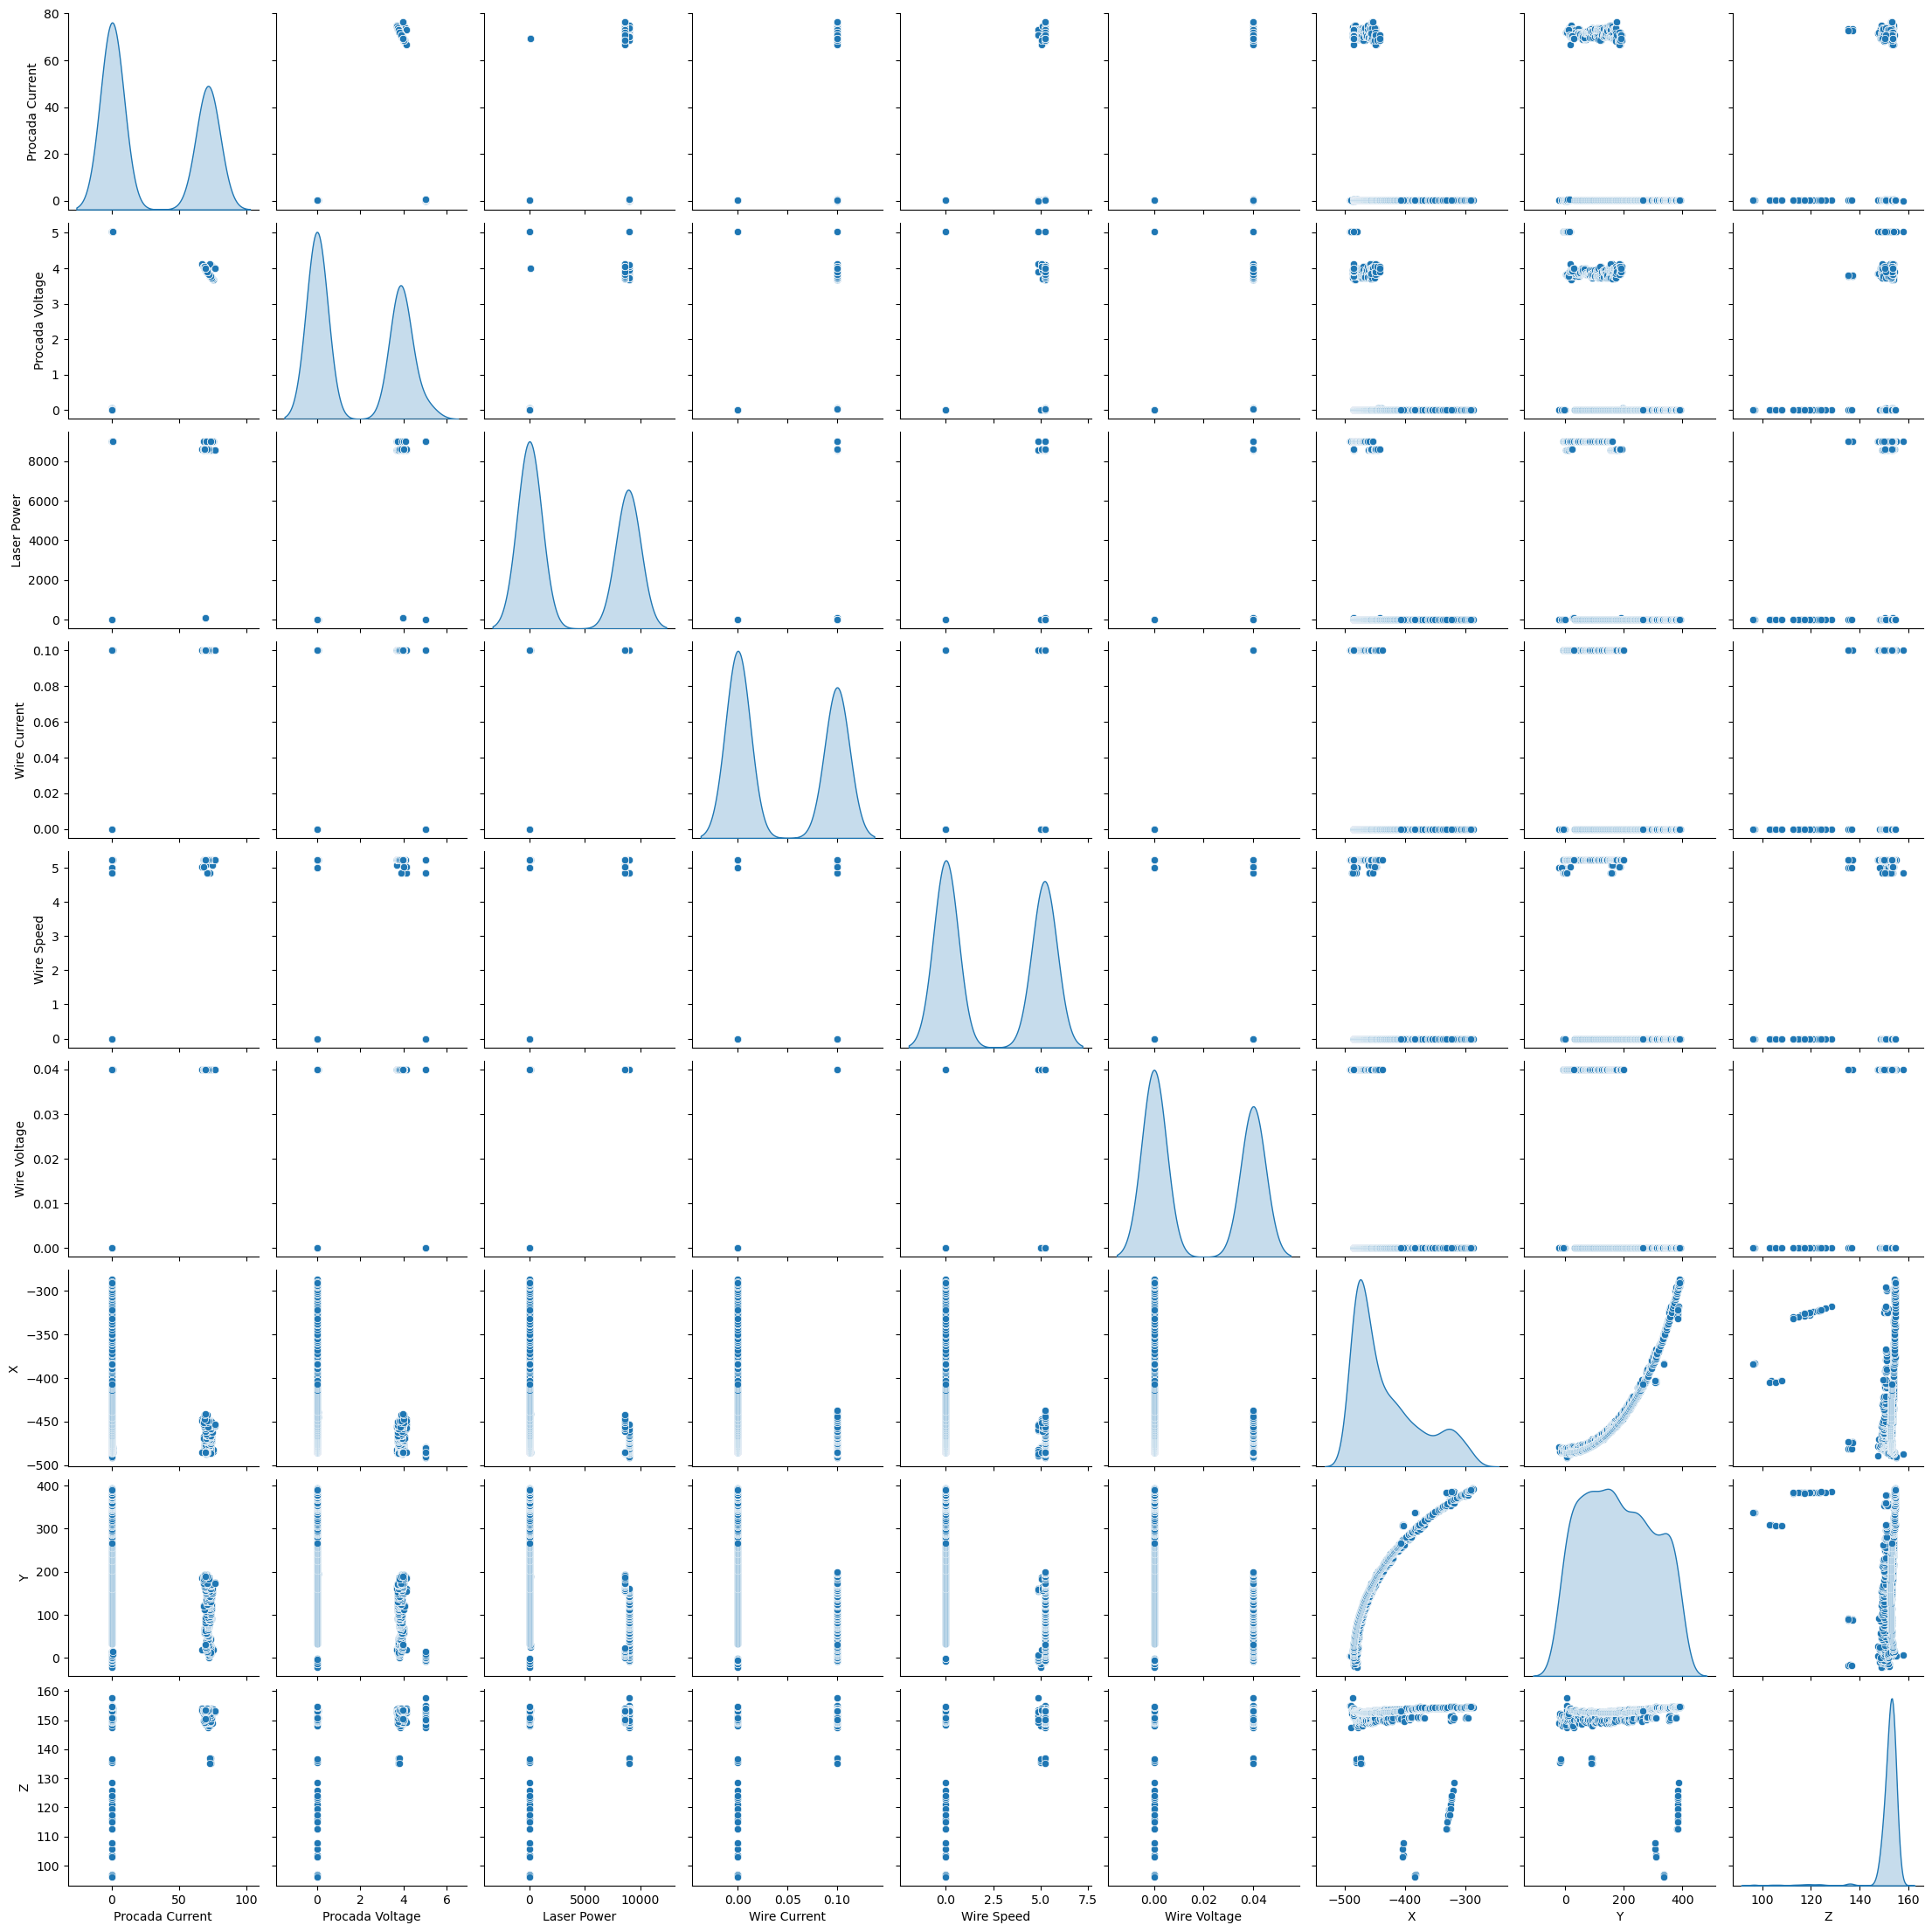

In [7]:
key_features = ['Procada Current', 'Procada Voltage', 'Laser Power', 
                'Wire Current', 'Wire Speed', 'Wire Voltage', 
                'X', 'Y', 'Z']

sns.pairplot(df[key_features], diag_kind = 'kde')
save_plot(plt, 'pairwise_plots.png', plot_dir)
plt.show()

Time Series Analysis

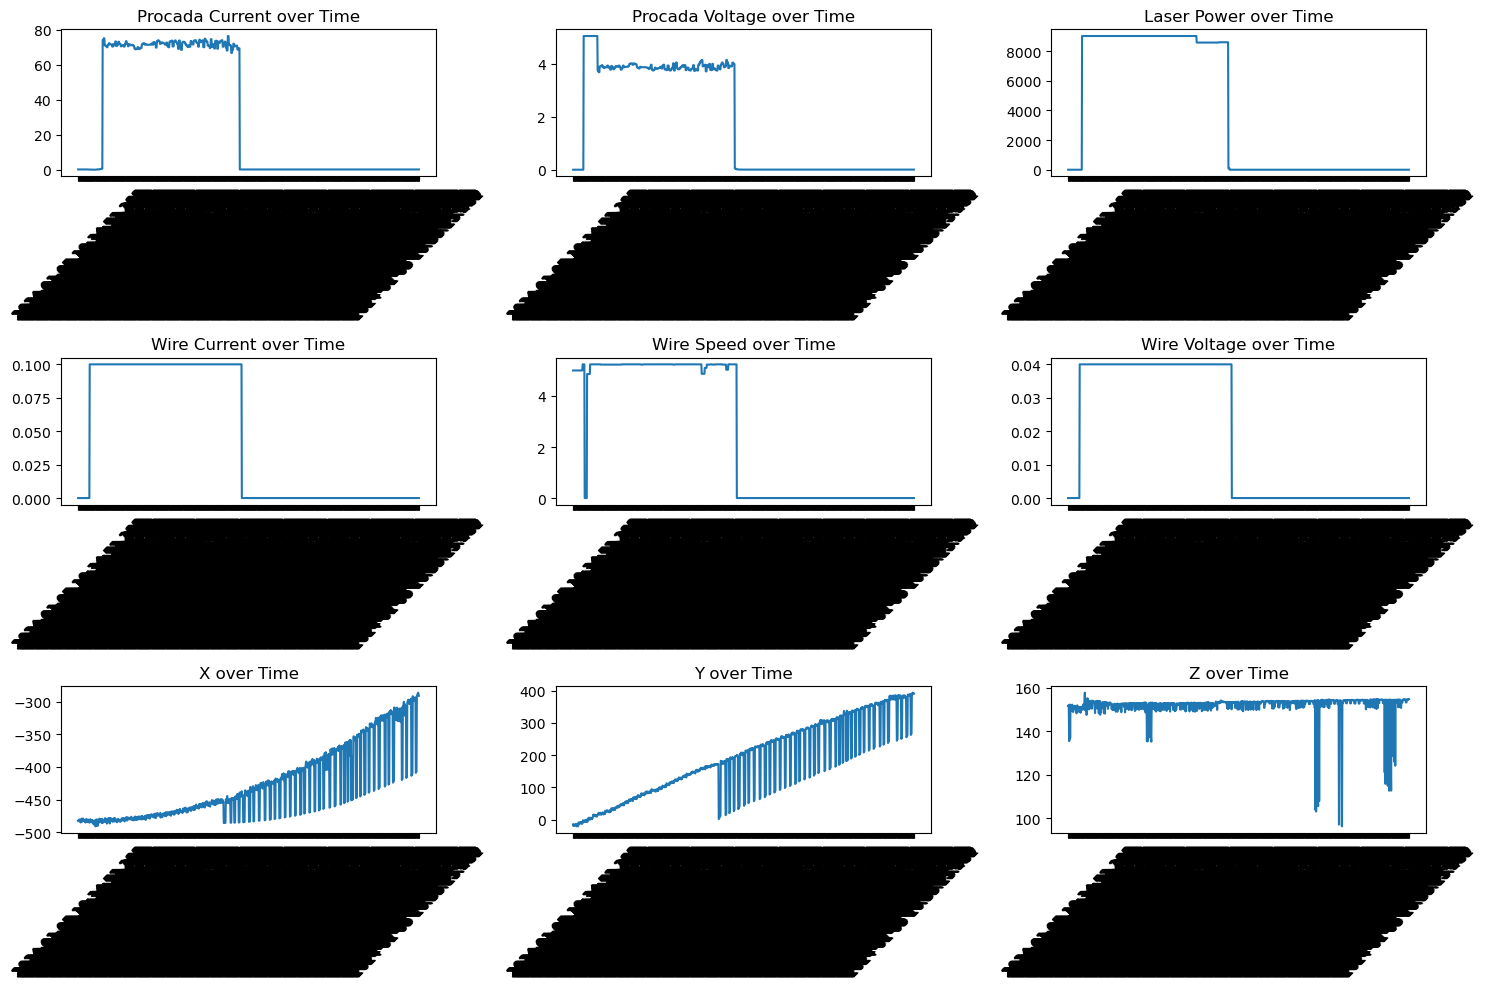

In [8]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(key_features, 1):
    plt.subplot(3, 3, i)
    plt.plot(df['Datetime'], df[feature])
    plt.title(f'{feature} over Time')
    plt.xticks(rotation = 45)
plt.tight_layout()
save_plot(plt, 'time_series.png', plot_dir)
#plt.close()
plt.show()

Feature Distribution Analysis

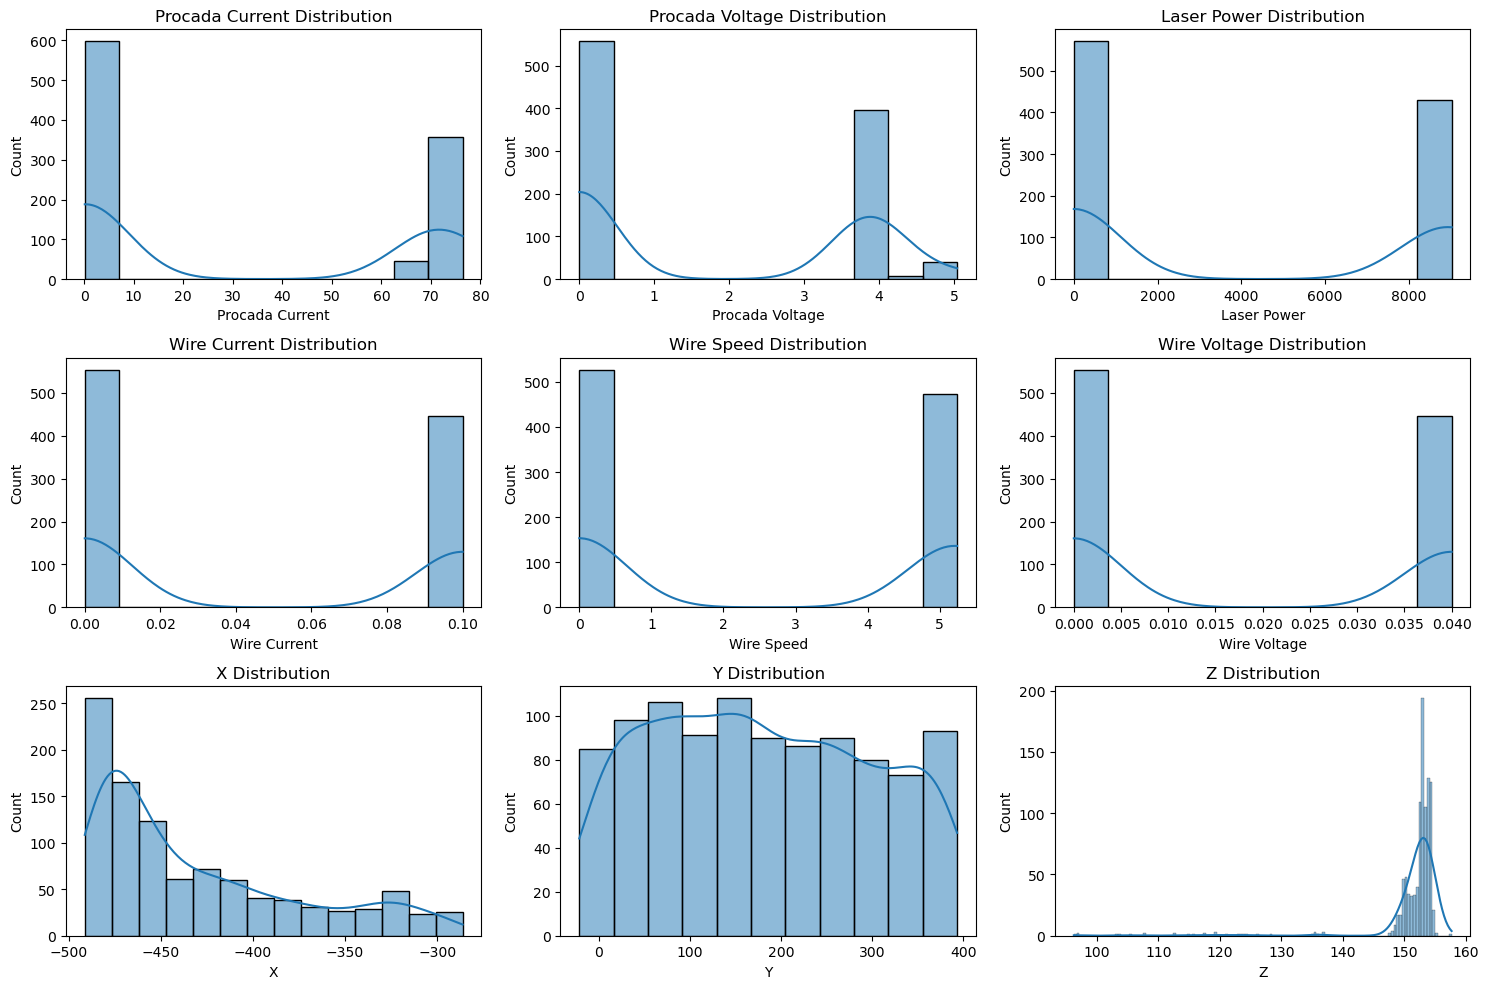

In [9]:
plt.figure(figsize = (15, 10))
for i, feature in enumerate(key_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[feature], kde = True)
    plt.title(f'{feature} Distribution')
plt.tight_layout()
save_plot(plt, 'distributions.png', plot_dir)
#plt.close()
plt.show()

Determine the key correlations.

In [10]:
print("\nKey Correlations:")
for feature1 in key_features:
    for feature2 in key_features:
        if feature1 < feature2:  # To avoid printing duplicates
            correlation = df[feature1].corr(df[feature2])
            if abs(correlation) > 0.5:  # Only show strong correlations
                print(f"{feature1} vs {feature2}: {correlation:.3f}")


Key Correlations:
Procada Current vs Procada Voltage: 0.867
Procada Current vs Wire Current: 0.913
Procada Current vs Wire Speed: 0.871
Procada Current vs Wire Voltage: 0.913
Procada Current vs X: -0.575
Procada Current vs Y: -0.552
Procada Voltage vs Wire Current: 0.972
Procada Voltage vs Wire Speed: 0.903
Procada Voltage vs Wire Voltage: 0.972
Procada Voltage vs X: -0.647
Procada Voltage vs Y: -0.681
Laser Power vs Procada Current: 0.928
Laser Power vs Procada Voltage: 0.955
Laser Power vs Wire Current: 0.966
Laser Power vs Wire Speed: 0.919
Laser Power vs Wire Voltage: 0.966
Laser Power vs X: -0.626
Laser Power vs Y: -0.637
Wire Current vs Wire Speed: 0.923
Wire Current vs Wire Voltage: 1.000
Wire Current vs X: -0.643
Wire Current vs Y: -0.657
Wire Speed vs Wire Voltage: 0.923
Wire Speed vs X: -0.690
Wire Speed vs Y: -0.741
Wire Voltage vs X: -0.643
Wire Voltage vs Y: -0.657
X vs Y: 0.943


Basic Statistics for each feature

In [11]:
print("\nFeature Statistics (in their respective units):")
for feature in key_features:
    stats_dict = {
        'Mean': df[feature].mean(),
        'Std': df[feature].std(),
        'Min': df[feature].min(),
        'Max': df[feature].max(),
        'Median': df[feature].median()
    }
    print(f"\n{feature}:")
    for stat, value in stats_dict.items():
        print(f"{stat}: {value:.3f}")


Feature Statistics (in their respective units):

Procada Current:
Mean: 28.965
Std: 35.024
Min: 0.134
Max: 76.390
Median: 0.275

Procada Voltage:
Mean: 1.766
Std: 1.989
Min: 0.000
Max: 5.039
Median: 0.004

Laser Power:
Mean: 3829.398
Std: 4420.988
Min: 0.000
Max: 9020.000
Median: 0.000

Wire Current:
Mean: 0.045
Std: 0.050
Min: 0.000
Max: 0.100
Median: 0.000

Wire Speed:
Mean: 2.462
Std: 2.601
Min: 0.000
Max: 5.240
Median: 0.000

Wire Voltage:
Mean: 0.018
Std: 0.020
Min: 0.000
Max: 0.040
Median: 0.000

X:
Mean: -430.760
Std: 55.501
Min: -491.213
Max: -286.253
Median: -453.475

Y:
Mean: 180.088
Std: 118.575
Min: -21.173
Max: 393.277
Median: 170.618

Z:
Mean: 151.535
Std: 6.431
Min: 96.233
Max: 157.680
Median: 152.868


Feature Importance Analysis

In [12]:
# Prepare data for feature importance analysis

X = df[key_features]
target_features = ['Procada Current', 'Procada Voltage', 'Laser Power']  # Multiple targets to analyze



Model Performance for Procada Current:
Mean Squared Error: 0.2705
Root Mean Squared Error: 0.5201

Model Performance for Procada Voltage:
Mean Squared Error: 0.0004
Root Mean Squared Error: 0.0201

Model Performance for Laser Power:
Mean Squared Error: 49823.8282
Root Mean Squared Error: 223.2125


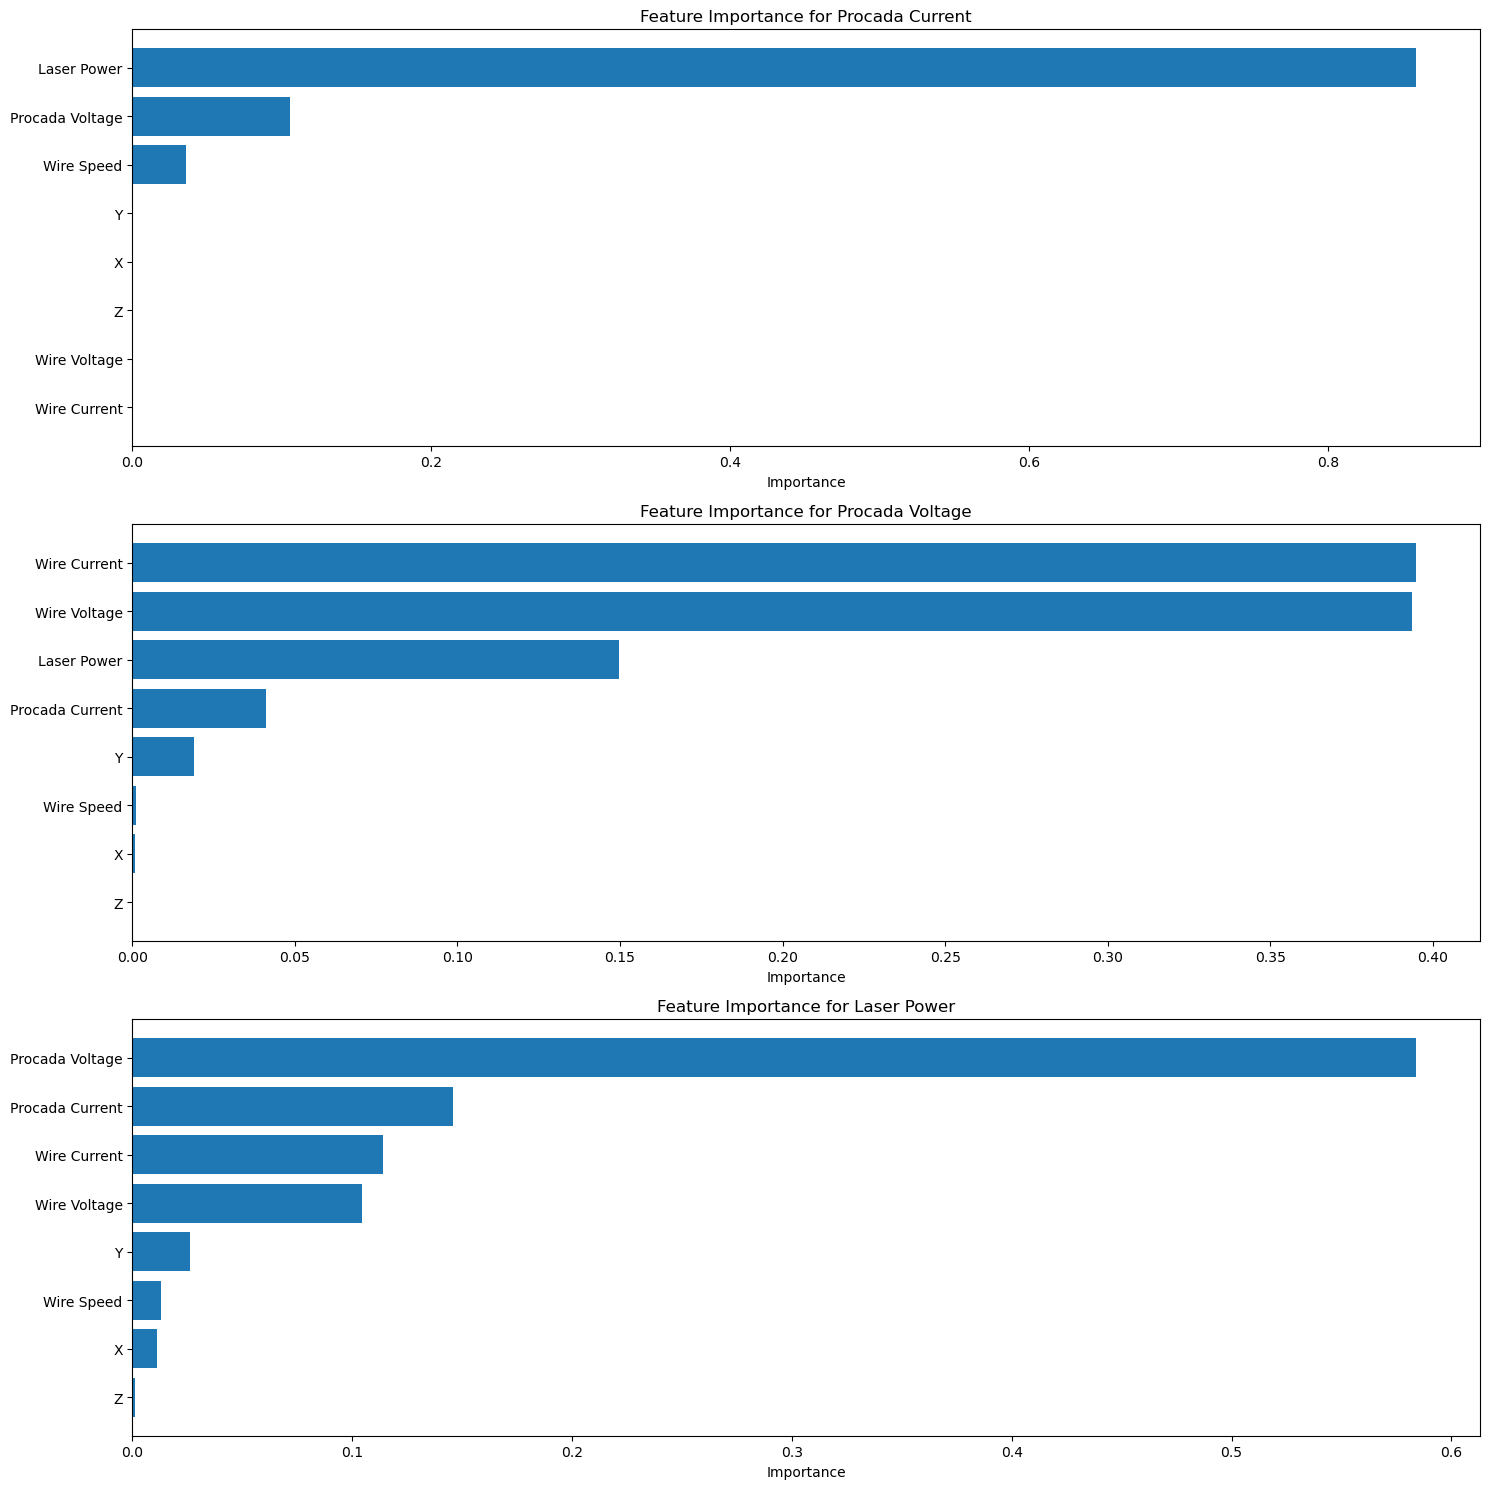

In [13]:
# Create feature importance plots for each target

plt.figure(figsize = (15, 15))
for idx, target in enumerate(target_features, 1):
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X.drop(target, axis=1), y, test_size=0.2, random_state=42
    )
    
    # Train Random Forest model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # Calculate feature importance
    importance = rf_model.feature_importances_
    features = X_train.columns
    
    # Plot feature importance
    plt.subplot(len(target_features), 1, idx)
    importance_df = pd.DataFrame({'features': features, 'importance': importance})
    importance_df = importance_df.sort_values('importance', ascending=True)
    
    plt.barh(range(len(importance)), importance_df['importance'])
    plt.yticks(range(len(importance)), importance_df['features'])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance for {target}')
    
    # Print model performance
    y_pred = rf_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"\nModel Performance for {target}:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Root Mean Squared Error: {np.sqrt(mse):.4f}")

plt.tight_layout()
save_plot(plt, 'feature_importance.png', plot_dir)
#plt.close()
plt.show()

Comprehensive Feature importance analysis.

In [14]:

def comprehensive_feature_importance(X, y, model=None):
    if model is None:
        # Explicitly use RandomForestRegressor as default
        model = RandomForestRegressor(n_estimators = 100, random_state = 42)
    
    # 1. Statistical Correlation
    corr = pd.DataFrame({'pearson': X.corrwith(y),
                        'spearman': X.corrwith(y, method='spearman')})
    
    # 2. Mutual Information
    mi = mutual_info_regression(X, y)
    
    # 3. Model-based importance (Random Forest Regressor)
    model.fit(X, y)
    model_importance = model.feature_importances_
    
    # 4. Permutation Importance
    perm_importance = permutation_importance(model, X, y, n_repeats=10)
    
    # 5. SHAP Values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    
    # Combine results
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Pearson_Correlation': corr['pearson'],
        'Spearman_Correlation': corr['spearman'],
        'Mutual_Information': mi,
        'Model_Importance': model_importance,
        'Permutation_Importance': perm_importance.importances_mean
    })
    
    return importance_df, shap_values


Feature Importance Analysis for Procada Current:

Importance Metrics:
                         Feature  Pearson_Correlation  Spearman_Correlation  \
Procada Voltage  Procada Voltage               0.8675                0.5773   
Laser Power          Laser Power               0.9282                0.8200   
Wire Current        Wire Current               0.9134                0.7998   
Wire Speed            Wire Speed               0.8709                0.8207   
Wire Voltage        Wire Voltage               0.9134                0.7998   
X                              X              -0.5749               -0.5190   
Y                              Y              -0.5525               -0.5298   
Z                              Z               0.0275               -0.3566   

                 Mutual_Information  Model_Importance  Permutation_Importance  
Procada Voltage              1.9411            0.1190                  0.1946  
Laser Power                  0.7686            0.8808    

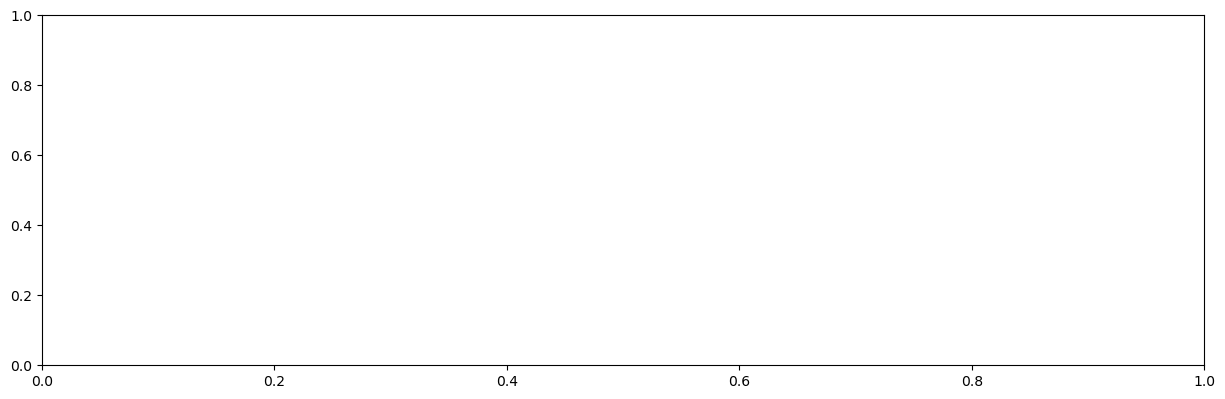

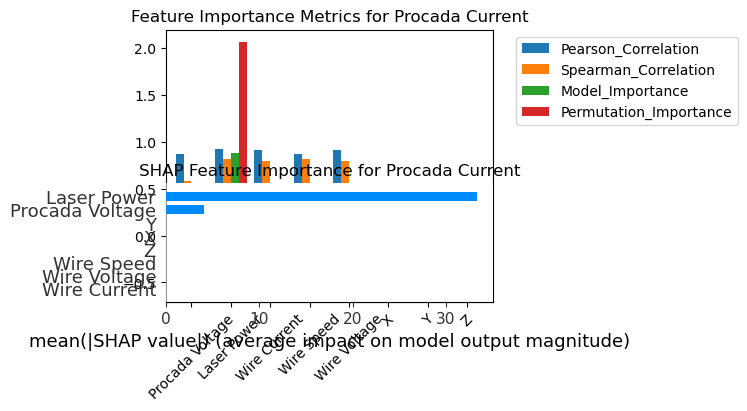


Feature Ranking Summary:

Laser Power:
  Average Rank: 2.67
  Pearson Correlation: 0.9282
  Model Importance: 0.8808

Procada Voltage:
  Average Rank: 3.67
  Pearson Correlation: 0.8675
  Model Importance: 0.1190

Wire Speed:
  Average Rank: 4.00
  Pearson Correlation: 0.8709
  Model Importance: 0.0000

Wire Voltage:
  Average Rank: 4.83
  Pearson Correlation: 0.9134
  Model Importance: 0.0000

Y:
  Average Rank: 4.83
  Pearson Correlation: -0.5525
  Model Importance: 0.0001

Z:
  Average Rank: 5.17
  Pearson Correlation: 0.0275
  Model Importance: 0.0000

Wire Current:
  Average Rank: 5.33
  Pearson Correlation: 0.9134
  Model Importance: 0.0000

X:
  Average Rank: 5.50
  Pearson Correlation: -0.5749
  Model Importance: 0.0001

Feature Importance Analysis for Procada Voltage:

Importance Metrics:
                         Feature  Pearson_Correlation  Spearman_Correlation  \
Procada Current  Procada Current               0.8675                0.5773   
Laser Power          Laser Power

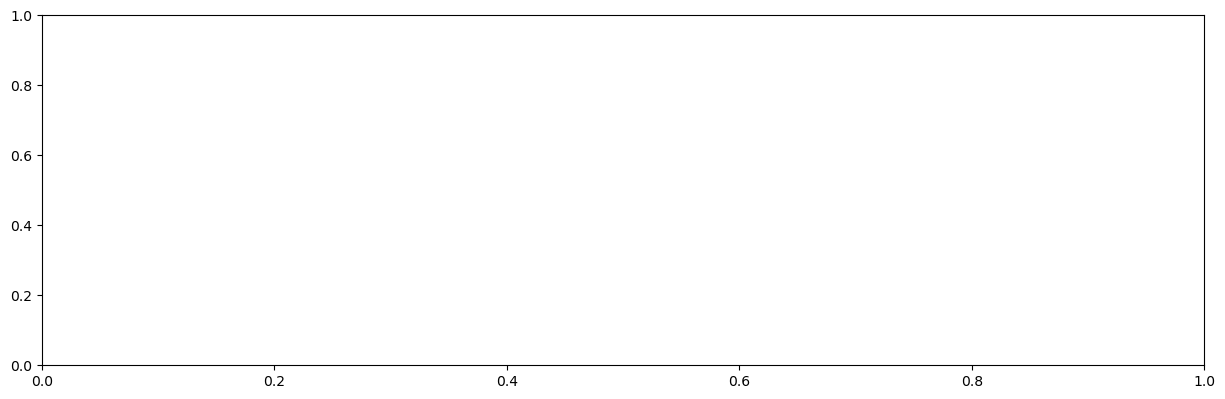

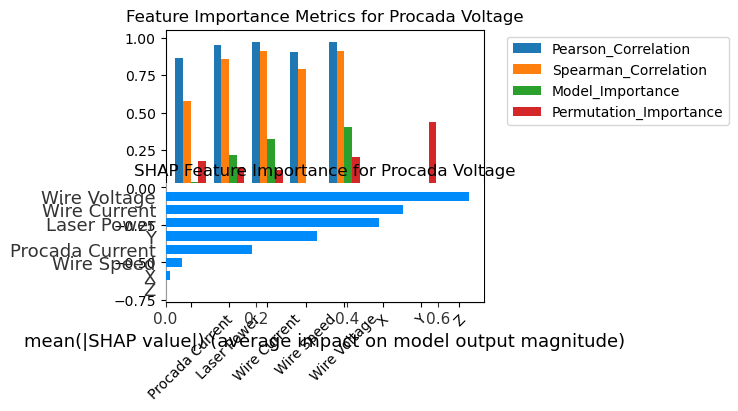


Feature Ranking Summary:

Wire Voltage:
  Average Rank: 2.67
  Pearson Correlation: 0.9721
  Model Importance: 0.4066

Wire Current:
  Average Rank: 3.50
  Pearson Correlation: 0.9721
  Model Importance: 0.3212

Procada Current:
  Average Rank: 4.17
  Pearson Correlation: 0.8675
  Model Importance: 0.0351

Laser Power:
  Average Rank: 4.17
  Pearson Correlation: 0.9545
  Model Importance: 0.2178

Y:
  Average Rank: 4.33
  Pearson Correlation: -0.6814
  Model Importance: 0.0180

Wire Speed:
  Average Rank: 4.50
  Pearson Correlation: 0.9026
  Model Importance: 0.0011

Z:
  Average Rank: 6.17
  Pearson Correlation: 0.0276
  Model Importance: 0.0000

X:
  Average Rank: 6.50
  Pearson Correlation: -0.6473
  Model Importance: 0.0003

Feature Importance Analysis for Laser Power:

Importance Metrics:
                         Feature  Pearson_Correlation  Spearman_Correlation  \
Procada Current  Procada Current               0.9282                0.8200   
Procada Voltage  Procada Voltage    

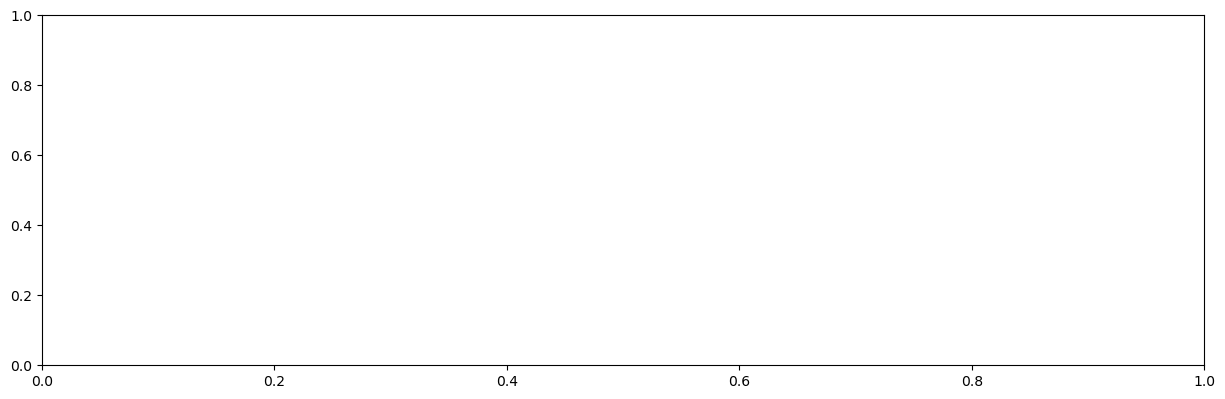

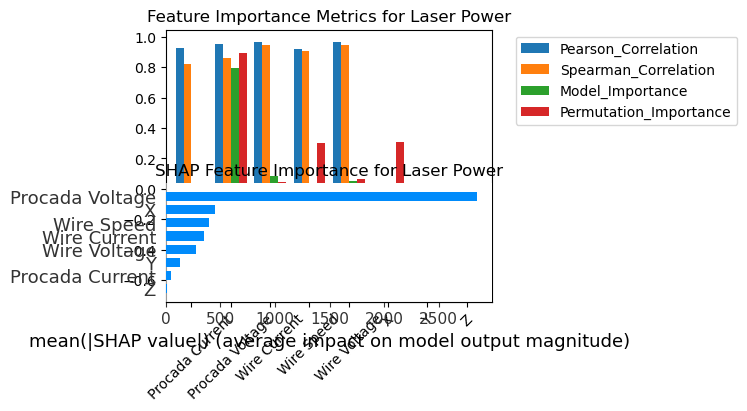


Feature Ranking Summary:

Wire Voltage:
  Average Rank: 3.00
  Pearson Correlation: 0.9659
  Model Importance: 0.0490

Procada Voltage:
  Average Rank: 3.17
  Pearson Correlation: 0.9545
  Model Importance: 0.7967

Wire Current:
  Average Rank: 3.50
  Pearson Correlation: 0.9659
  Model Importance: 0.0858

Wire Speed:
  Average Rank: 4.00
  Pearson Correlation: 0.9186
  Model Importance: 0.0169

Procada Current:
  Average Rank: 5.00
  Pearson Correlation: 0.9282
  Model Importance: 0.0194

X:
  Average Rank: 5.50
  Pearson Correlation: -0.6258
  Model Importance: 0.0094

Y:
  Average Rank: 5.67
  Pearson Correlation: -0.6367
  Model Importance: 0.0220

Z:
  Average Rank: 6.17
  Pearson Correlation: 0.0299
  Model Importance: 0.0008


In [15]:
# First, let's analyze feature importance for each target feature
target_features = ['Procada Current', 'Procada Voltage', 'Laser Power']

for target in target_features:
    # Prepare X and y
    X = df[key_features].drop(target, axis=1)  # Remove target from features
    y = df[target]
    
    # Run comprehensive analysis
    importance_df, shap_values = comprehensive_feature_importance(X, y)
    
    print(f"\nFeature Importance Analysis for {target}:")
    print("\nImportance Metrics:")
    print(importance_df.round(4))
    
    # Visualize results
    plt.figure(figsize=(15, 10))
    
    # 1. Bar plot of combined importance metrics
    plt.subplot(2, 1, 1)
    importance_df[['Pearson_Correlation', 'Spearman_Correlation', 'Model_Importance', 'Permutation_Importance']].plot(
        kind='bar', width=0.8)
    plt.title(f'Feature Importance Metrics for {target}')
    plt.xticks(range(len(importance_df)), importance_df['Feature'], rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 2. SHAP Summary Plot
    plt.subplot(2, 1, 2)
    shap.summary_plot(shap_values, X, plot_type="bar", show = False)  ##### False
    plt.title(f'SHAP Feature Importance for {target}')
    
    plt.tight_layout()
    save_plot(plt, f'comprehensive_importance_{target.replace(" ", "_")}.png', plot_dir)
    plt.show()
    
    # Print detailed analysis
    print("\nFeature Ranking Summary:")
    rankings = importance_df.rank(ascending=False)
    mean_rank = rankings.mean(axis=1).sort_values()
    
    for feature in mean_rank.index:
        print(f"\n{feature}:")
        print(f"  Average Rank: {mean_rank[feature]:.2f}")
        print(f"  Pearson Correlation: {importance_df.loc[importance_df['Feature'] == feature, 'Pearson_Correlation'].values[0]:.4f}")
        print(f"  Model Importance: {importance_df.loc[importance_df['Feature'] == feature, 'Model_Importance'].values[0]:.4f}")